# Notebook 3 — Carbon Metrics
## Section 3.1: Carbon Intensity and Carbon Footprint Analysis

This notebook computes and analyzes the carbon metrics of the portfolios
constructed in Notebook 2 (Part I). We consider Scope 1 + Scope 2 CO2
emissions for all firms in the European investment universe.

We compute:
- **Carbon Intensity (CI)**: tonnes of CO2 per million USD of revenue
- **Weighted Average Carbon Intensity (WACI)**: portfolio-level CI weighted by portfolio weights
- **Carbon Footprint (CF)**: annual CO2 emissions attributed to the investor per million USD invested

All carbon data is annual. The allocation is based on information available
at the end of year Y, applied to year Y+1.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent
CLEAN_DIR = BASE_DIR / "data_clean"
RAW_DIR   = BASE_DIR / "data_raw"

# 1. Load Data

We load all cleaned datasets plus the portfolio weights saved from Notebook 2.

In [38]:
# Load cleaned data
scope1_clean   = pd.read_excel(CLEAN_DIR / "scope1_clean.xlsx")
scope2_clean   = pd.read_excel(CLEAN_DIR / "scope2_clean.xlsx")
revenues_clean = pd.read_excel(CLEAN_DIR / "revenues_clean.xlsx")
mv_year_clean  = pd.read_excel(CLEAN_DIR / "market_value_year_clean.xlsx")
mv_month_clean = pd.read_excel(CLEAN_DIR / "market_value_month_clean.xlsx")
static         = pd.read_excel(RAW_DIR / "Static_2025.xlsx")

# Load portfolio weights saved from Notebook 2
# (we will re-run the MV loop here to get all_weights,
#  or you can save/load them — see note below)

# Load returns matrix (needed to recompute all_weights if not saved)
returns_raw = pd.read_excel(CLEAN_DIR / "returns_monthly_clean.xlsx")

print("All data loaded.")

All data loaded.


# 2. Build Carbon Data

We compute the total CO2 emissions for each firm and year as:

**Eᵢ,Y = Scope1ᵢ,Y + Scope2ᵢ,Y**

We then compute the carbon intensity (CI) as:

**CIᵢ,Y = Eᵢ,Y / Revᵢ,Y**

where revenues are already in millions USD (converted in the cleaning notebook).

Note: carbon data covers 2002–2024. We use data available at end of year Y
for the portfolio allocated over year Y+1.

In [39]:
# Set ISIN as index for all annual datasets
def to_isin_index(df):
    return df.set_index("ISIN").drop(columns=["NAME"], errors="ignore")

scope1 = to_isin_index(scope1_clean)
scope2 = to_isin_index(scope2_clean)
revenues = to_isin_index(revenues_clean)
mv_year = to_isin_index(mv_year_clean)

# Convert column names to integers (years)
scope1.columns   = scope1.columns.astype(int)
scope2.columns   = scope2.columns.astype(int)
revenues.columns = revenues.columns.astype(int)
mv_year.columns  = mv_year.columns.astype(int)

# Filter to Europe
static_europe = static[static["Region"].str.upper() == "EUR"].copy()
isins_europe  = set(static_europe["ISIN"])

scope1   = scope1[scope1.index.isin(isins_europe)]
scope2   = scope2[scope2.index.isin(isins_europe)]
revenues = revenues[revenues.index.isin(isins_europe)]
mv_year  = mv_year[mv_year.index.isin(isins_europe)]

print("scope1:",   scope1.shape)
print("scope2:",   scope2.shape)
print("revenues:", revenues.shape)
print("mv_year:",  mv_year.shape)

scope1: (620, 26)
scope2: (622, 26)
revenues: (630, 27)
mv_year: (633, 27)


In [40]:
# Align all datasets to common ISINs
common_isins = (
    set(scope1.index)
    & set(scope2.index)
    & set(revenues.index)
    & set(mv_year.index)
)
common_isins = sorted(common_isins)
print(f"Firms with full carbon + revenue + market cap data: {len(common_isins)}")

scope1   = scope1.loc[common_isins]
scope2   = scope2.loc[common_isins]
revenues = revenues.loc[common_isins]
mv_year  = mv_year.loc[common_isins]

# Total emissions: Scope 1 + Scope 2 (in tonnes CO2)
# Align on common years
common_years = sorted(
    set(scope1.columns)
    & set(scope2.columns)
    & set(revenues.columns)
    & set(mv_year.columns)
)
print(f"Common years: {common_years[0]} to {common_years[-1]}")

emissions = scope1[common_years].add(scope2[common_years], fill_value=0)

# Carbon intensity: tonnes CO2 per million USD revenue
# revenues already in millions USD
carbon_intensity = emissions.div(revenues[common_years].replace(0, np.nan))

print("Emissions matrix shape:",        emissions.shape)
print("Carbon intensity matrix shape:", carbon_intensity.shape)

Firms with full carbon + revenue + market cap data: 618
Common years: 1999 to 2024
Emissions matrix shape: (618, 26)
Carbon intensity matrix shape: (618, 26)


# 3. Rebuild Investment Set and Portfolio Weights

We reload the MV portfolio weights (from Notebook 2) by re-running
the investment set construction. This gives us `all_weights` —
a dictionary mapping each year to a Series of portfolio weights indexed by ISIN.

We also reconstruct the value-weighted portfolio weights for each year.

In [43]:
from scipy.optimize import minimize

# Rebuild returns matrix
returns_matrix = returns_raw[returns_raw["ISIN"].isin(isins_europe)].copy()
returns_matrix = returns_matrix.set_index("ISIN").drop(columns=["NAME"])
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)
returns_matrix = returns_matrix.sort_index(axis=1)

isins_scope1 = set(scope1_clean["ISIN"])
isins_scope2 = set(scope2_clean["ISIN"])
has_carbon_global = pd.Series(
    returns_matrix.index.isin(isins_scope1 | isins_scope2),
    index=returns_matrix.index
)

# Pre-compute e_over_cap for all years
e_over_cap_all = {}
for year in range(2013, 2025):
    if year in emissions.columns and year in mv_year.columns:
        e_over_cap_all[year] = emissions[year].div(mv_year[year].replace(0, np.nan))

start_year = 2013
end_year   = 2024
window     = 120

all_weights          = {}
mv_portfolio_returns = []
mv_dates             = []

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue

    past_ret = returns_matrix[past_cols]

    # Filter (a): at least 36 non-NaN observations
    enough_obs = past_ret.notna().sum(axis=1) >= 36

    # Filter (b): stale price filter
    non_nan_count = past_ret.notna().sum(axis=1).replace(0, np.nan)
    zero_count    = (past_ret == 0).sum(axis=1)
    not_stale     = (zero_count / non_nan_count) <= 0.5

    # Filter (c): valid price at end of year Y
    has_price = past_ret[past_cols[-1]].notna()

    # Filter (d): carbon data available
    has_carbon = has_carbon_global

    # Combine filters (a)-(d)
    valid       = enough_obs & not_stale & has_price & has_carbon
    valid_isins = valid[valid].index.tolist()

    # Filter (e): exclude firms with E/Cap ratio above 3x the VW carbon footprint
    if year in e_over_cap_all:
        e_over_cap_y = e_over_cap_all[year]
        cap_year_vw  = mv_year[year].dropna()
        e_year_vw    = emissions[year].dropna()
        common_vw    = cap_year_vw.index.intersection(e_year_vw.index)
        if len(common_vw) > 0:
            cf_vw_year = e_year_vw[common_vw].sum() / cap_year_vw[common_vw].sum()
            threshold  = 3 * cf_vw_year
        else:
            threshold  = e_over_cap_y.quantile(0.95)
        e_valid     = e_over_cap_y.reindex(valid_isins).dropna()
        valid_isins = [i for i in valid_isins if
                       i not in e_valid.index or e_over_cap_y.get(i, 0) <= threshold]

    if len(valid_isins) < 10:
        print(f"Year {year}: too few valid firms ({len(valid_isins)}), skipping")
        continue

    print(f"Year {year}: {len(valid_isins)} firms in investment set")

    sub        = past_ret.loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    def portfolio_variance(w):
        return w @ Sigma @ w

    def portfolio_variance_grad(w):
        return 2 * Sigma @ w

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1,
                    'jac': lambda w: np.ones(N)}]
    bounds = [(0, 0.05)] * N
    w0     = np.ones(N) / N

    result = minimize(
        portfolio_variance, w0,
        jac=portfolio_variance_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    all_weights[year] = pd.Series(w, index=valid_isins)

    # Next-year monthly returns with weight drift — using numpy for speed
    next_cols = returns_matrix.columns[
        (returns_matrix.columns > end_date) &
        (returns_matrix.columns <= end_date + pd.DateOffset(years=1))
    ]

    if len(next_cols) == 0:
        continue

    next_ret  = returns_matrix.loc[valid_isins, next_cols].fillna(0).values
    w_current = w.copy()

    for k in range(next_ret.shape[1]):
        r_t       = next_ret[:, k]
        rp_t      = float(w_current @ r_t)
        mv_portfolio_returns.append(rp_t)
        mv_dates.append(next_cols[k])
        w_current = w_current * (1 + r_t)
        total     = w_current.sum()
        if total > 0:
            w_current = w_current / total

mv_returns = pd.Series(mv_portfolio_returns, index=mv_dates).sort_index()
print(f"\nMV weights computed for years: {sorted(all_weights.keys())}")
print(f"MV returns shape: {mv_returns.shape}")

Year 2013: 572 firms in investment set
Year 2014: 569 firms in investment set
Year 2015: 568 firms in investment set
Year 2016: 565 firms in investment set
Year 2017: 568 firms in investment set
Year 2018: 564 firms in investment set
Year 2019: 556 firms in investment set
Year 2020: 545 firms in investment set
Year 2021: 544 firms in investment set
Year 2022: 531 firms in investment set
Year 2023: 516 firms in investment set
Year 2024: 500 firms in investment set

MV weights computed for years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
MV returns shape: (144,)


# 4. Weighted Average Carbon Intensity (WACI)

The WACI of the portfolio is computed each year as:

**WACIᴾY = Σᵢ αᵢ,Y × CIᵢ,Y**

where αᵢ,Y are the portfolio weights at end of year Y and
CIᵢ,Y is the carbon intensity of firm i in year Y.

We compute this for both the MV portfolio and the VW benchmark.

In [44]:
# Compute WACI for MV portfolio
waci_mv = {}

for year, weights in all_weights.items():
    if year not in common_years:
        continue
    ci_year = carbon_intensity[year]
    # align weights and CI on common ISINs
    common = weights.index.intersection(ci_year.dropna().index)
    if len(common) == 0:
        continue
    w  = weights[common]
    w  = w / w.sum()  # renormalize after alignment
    ci = ci_year[common]
    waci_mv[year] = (w * ci).sum()

waci_mv = pd.Series(waci_mv).sort_index()
print("WACI MV portfolio:")
print(waci_mv)

WACI MV portfolio:
2013     46.702875
2014     31.547613
2015     38.575608
2016     35.664339
2017     37.243644
2018     36.944781
2019     81.406610
2020    107.941737
2021    105.606458
2022     37.132159
2023     19.249348
2024     18.177928
dtype: float64


In [45]:
# Compute WACI for VW portfolio
# VW weight of firm i at end of year Y = Cap_i,Y / sum(Cap_j,Y)
waci_vw = {}

for year in sorted(all_weights.keys()):
    if year not in common_years:
        continue
    if year not in mv_year.columns:
        continue

    caps    = mv_year[year].dropna()
    ci_year = carbon_intensity[year].dropna()

    common  = caps.index.intersection(ci_year.index)
    if len(common) == 0:
        continue

    caps    = caps[common]
    ci_year = ci_year[common]
    w_vw    = caps / caps.sum()
    waci_vw[year] = (w_vw * ci_year).sum()

waci_vw = pd.Series(waci_vw).sort_index()
print("WACI VW portfolio:")
print(waci_vw)

WACI VW portfolio:
2013    140.375106
2014    128.220920
2015    155.055924
2016    149.935453
2017    171.249395
2018    134.724368
2019    138.834478
2020    132.756954
2021    134.691536
2022    106.375604
2023     79.593174
2024    107.919348
dtype: float64


# 5. Carbon Footprint (CF)

The carbon footprint measures the total annual CO2 emissions
attributed to the investor per million USD invested:

**CFᴾY = (1/VY) × Σᵢ (αᵢ,Y × VY / Capᵢ,Y) × Eᵢ,Y**

which simplifies to:

**CFᴾY = Σᵢ αᵢ,Y × (Eᵢ,Y / Capᵢ,Y)**

We assume a starting wealth of V₂₀₁₃ = 1 million USD.

In [46]:
# Carbon footprint for MV portfolio
cf_mv = {}

for year, weights in all_weights.items():
    if year not in common_years:
        continue
    if year not in mv_year.columns:
        continue

    e_year   = emissions[year]
    cap_year = mv_year[year]

    # emissions in tonnes, cap in million USD
    e_over_cap = e_year.div(cap_year.replace(0, np.nan))

    # Only use firms that appear in both weights AND have valid e_over_cap
    common = weights.index.intersection(e_over_cap.dropna().index)
    if len(common) == 0:
        continue

    w  = weights[common]
    # Do NOT renormalize here — keep original weights, just set missing to 0
    cf_mv[year] = (w * e_over_cap[common]).sum()

cf_mv = pd.Series(cf_mv).sort_index()
print("Carbon Footprint MV portfolio (tonnes CO2 per million USD invested):")
print(cf_mv)

Carbon Footprint MV portfolio (tonnes CO2 per million USD invested):
2013    19.361032
2014    15.134344
2015    14.342699
2016    12.729473
2017    15.951327
2018    18.940651
2019    33.169196
2020    36.446055
2021    33.105337
2022    20.705832
2023    23.454897
2024    24.215487
dtype: float64


In [47]:
# Carbon footprint for VW portfolio
# CF_vw = (1/Cap_total) * sum_i E_i,Y
# which equals sum_i w_vw_i * (E_i,Y / Cap_i,Y)

cf_vw = {}

for year in sorted(all_weights.keys()):
    if year not in common_years:
        continue
    if year not in mv_year.columns:
        continue

    e_year   = emissions[year].dropna()
    cap_year = mv_year[year].dropna()

    common   = e_year.index.intersection(cap_year.index)
    if len(common) == 0:
        continue

    e_year   = e_year[common]
    cap_year = cap_year[common]

    # CF_vw = sum(E_i) / sum(Cap_i)
    cf_vw[year] = e_year.sum() / cap_year.sum()

cf_vw = pd.Series(cf_vw).sort_index()
print("Carbon Footprint VW portfolio (tonnes CO2 per million USD invested):")
print(cf_vw)

Carbon Footprint VW portfolio (tonnes CO2 per million USD invested):
2013    222.244822
2014    187.148048
2015    193.906603
2016    204.880949
2017    184.999453
2018    143.520371
2019    153.163639
2020    125.909341
2021    118.582262
2022     98.442947
2023     97.277101
2024     90.532843
dtype: float64


# 6. Plots — WACI and Carbon Footprint Over Time

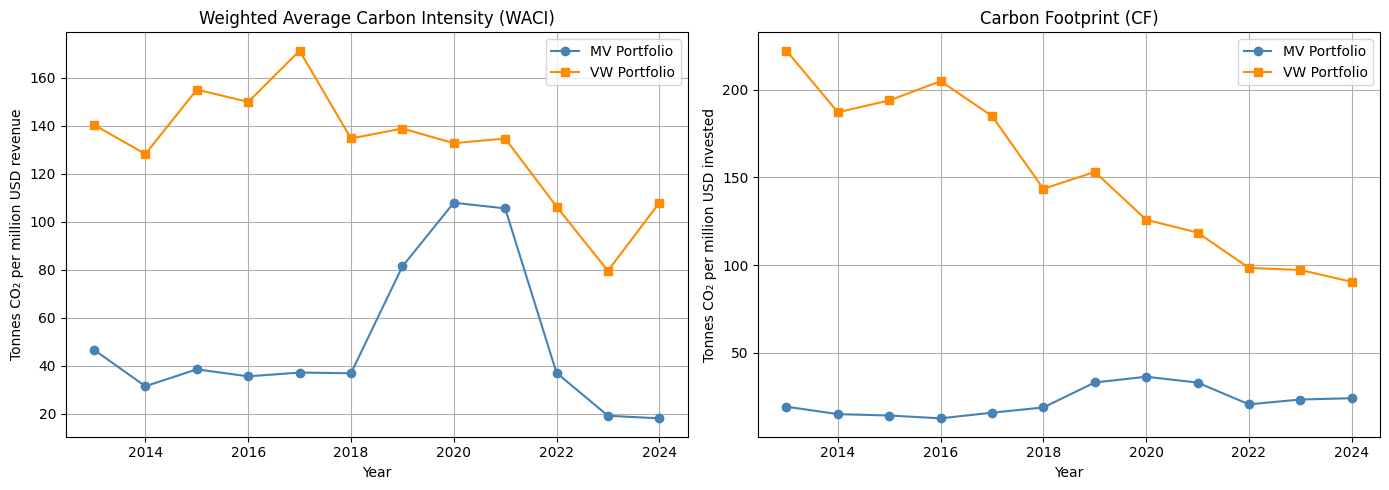

In [48]:
import os

# Create outputs folder if it doesn't exist
os.makedirs(BASE_DIR / "outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WACI
axes[0].plot(waci_mv.index, waci_mv.values, marker='o',
             label="MV Portfolio", color="steelblue")
axes[0].plot(waci_vw.index, waci_vw.values, marker='s',
             label="VW Portfolio", color="darkorange")
axes[0].set_title("Weighted Average Carbon Intensity (WACI)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Tonnes CO₂ per million USD revenue")
axes[0].legend()
axes[0].grid(True)

# Carbon Footprint
axes[1].plot(cf_mv.index, cf_mv.values, marker='o',
             label="MV Portfolio", color="steelblue")
axes[1].plot(cf_vw.index, cf_vw.values, marker='s',
             label="VW Portfolio", color="darkorange")
axes[1].set_title("Carbon Footprint (CF)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Tonnes CO₂ per million USD invested")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "carbon_metrics.png", dpi=150)
plt.show()

# 7. Top 10 Firms Driving Carbon Intensity

We identify the firms with the highest contribution to portfolio
carbon intensity, averaged over the full sample period.
We report firm names and ISIN codes.

In [49]:
# Average CI contribution per firm across all years, weighted by MV weights
ci_contribution = {}

for year, weights in all_weights.items():
    if year not in common_years:
        continue
    ci_year = carbon_intensity[year]
    common  = weights.index.intersection(ci_year.dropna().index)
    if len(common) == 0:
        continue
    w  = weights[common]
    w  = w / w.sum()
    contrib = (w * ci_year[common])
    for isin, val in contrib.items():
        ci_contribution[isin] = ci_contribution.get(isin, []) + [val]

# Average contribution over years
avg_contrib = {isin: np.mean(vals) for isin, vals in ci_contribution.items()}
avg_contrib = pd.Series(avg_contrib).sort_values(ascending=False)

# Map ISIN to firm name — check actual column name
print("Static columns:", static.columns.tolist())  # check the exact column name

# Use whichever name appears in the print above
name_col = [c for c in static.columns if c.lower() == "name"][0]
isin_to_name = static.set_index("ISIN")[name_col].to_dict()

top10 = avg_contrib.head(10).reset_index()
top10.columns = ["ISIN", "Avg CI Contribution"]
top10["Firm Name"] = top10["ISIN"].map(isin_to_name)
top10 = top10[["Firm Name", "ISIN", "Avg CI Contribution"]]

print("\nTop 10 firms driving carbon intensity in the MV portfolio:")
print(top10.to_string(index=False))

Static columns: ['ISIN', 'NAME', 'Country', 'Region']

Top 10 firms driving carbon intensity in the MV portfolio:
                             Firm Name         ISIN  Avg CI Contribution
                            ELIA GROUP BE0003822393            14.001663
                         ICTL.HTLS.GP. GB00BHJYC057             5.136678
                     KONINKLIJKE VOPAK NL0009432491             5.092952
                         NATIONAL GRID GB00BDR05C01             3.952461
          DEVRO DEAD - DELIST.14/04/23 GB0002670437             2.703136
                         COCA-COLA HBC CH0198251305             2.508759
                                  MOWI NO0003054108             2.127780
                UNITED UTILITIES GROUP GB00B39J2M42             1.908003
        DIGNITY DEAD - DELIST.25/05/23 GB00BRB37M78             1.669844
TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1 US8816242098             1.557395


## 8. Save Carbon Metrics for use in Notebook 4

We save the carbon footprint series and carbon intensity data
so that Notebook 4 can use them as constraints without recomputing.

In [50]:
# Save for Notebook 4
cf_mv.to_excel(CLEAN_DIR / "cf_mv.xlsx",  header=["CF_MV"])
cf_vw.to_excel(CLEAN_DIR / "cf_vw.xlsx",  header=["CF_VW"])
waci_mv.to_excel(CLEAN_DIR / "waci_mv.xlsx", header=["WACI_MV"])
waci_vw.to_excel(CLEAN_DIR / "waci_vw.xlsx", header=["WACI_VW"])

# Save emissions and carbon intensity matrices
emissions.to_excel(CLEAN_DIR / "emissions.xlsx")
carbon_intensity.to_excel(CLEAN_DIR / "carbon_intensity.xlsx")

# Save MV weights dict as a single DataFrame
weights_df = pd.DataFrame(all_weights).T  # years x ISINs
weights_df.index.name = "year"
weights_df.to_excel(CLEAN_DIR / "mv_weights.xlsx")

print("All carbon metrics saved.")

All carbon metrics saved.


## 9. Summary

This notebook has computed:

- **Emissions** (Scope 1 + Scope 2) for all European firms over 2013–2024
- **Carbon Intensity (CI)** in tonnes CO₂ per million USD revenue
- **WACI** for both the MV and VW portfolios over the full sample
- **Carbon Footprint (CF)** for both portfolios over the full sample
- **Top 10 firms** contributing most to portfolio carbon intensity

Key observations:
- Compare WACI and CF levels between MV and VW
- Note whether the MV portfolio is naturally more or less carbon intensive than the market
- The top 10 firms will reveal which sectors drive emissions up

These metrics feed directly into the constrained optimization in Notebook 4.